In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
nav = pd.read_csv("D:\mutual fund project\day 2 Cleaned data  SQLite DB loaded\Data\\raw\\02_nav_history.csv")
transactions = pd.read_csv("D:\mutual fund project\day 2 Cleaned data  SQLite DB loaded\Data\\raw\\08_investor_transactions.csv")
funds = pd.read_csv("D:\mutual fund project\day 2 Cleaned data  SQLite DB loaded\Data\\raw\\01_fund_master.csv")

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\sktec\AppData\Local\Temp\ipykernel_27784\3033080093.py:1: SyntaxWarning: invalid escape sequence '\m'
  nav = pd.read_csv("D:\mutual fund project\day 2 Cleaned data  SQLite DB loaded\Data\\raw\\02_nav_history.csv")
C:\Users\sktec\AppData\Local\Temp\ipykernel_27784\3033080093.py:2: SyntaxWarning: invalid escape sequence '\m'
  transactions = pd.read_csv("D:\mutual fund project\day 2 Cleaned data  SQLite DB loaded\Data\\raw\\08_investor_transactions.csv")
C:\Users\sktec\AppData\Local\Temp\ipykernel_27784\3033080093.py:3: SyntaxWarning: invalid escape sequence '\m'
  funds = pd.read_csv("D:\mutual fund project\day 2 Cleaned data  SQLite DB loaded\Data\\raw\\01_fund_master.csv")


In [8]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [4]:
nav.head()

transactions.head()

funds.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


Convert date columns

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [12]:
nav = nav.sort_values(["amfi_code", "date"])

Historical VaR and CVaR

In [9]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [13]:
nav = nav.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [14]:
results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    scheme = group["scheme_name"].iloc[0]

    results.append({
        "amfi_code": code,
        "scheme_name": scheme,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

In [15]:
risk_report = pd.DataFrame(results)

In [16]:
risk_report = risk_report.sort_values("VaR_95")

In [17]:
print(risk_report.head(10))

    amfi_code                                        scheme_name    VaR_95  \
22     119599          SBI Small Cap Fund - Direct Plan - Growth -0.026859   
17     119095             Axis Small Cap Fund - Regular - Growth -0.026188   
4      101207             ABSL Small Cap Fund - Regular - Growth -0.026021   
11     118634     Nippon India Small Cap Fund - Regular - Growth -0.025438   
21     119598         SBI Small Cap Fund - Regular Plan - Growth -0.024507   
39     149324              DSP Small Cap Fund - Regular - Growth -0.023483   
7      102886                UTI Mid Cap Fund - Regular - Growth -0.019220   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr... -0.019034   
25     120505           ICICI Pru Midcap Fund - Regular - Growth -0.018892   
16     119094                Axis Midcap Fund - Regular - Growth -0.018480   

     CVaR_95  
22 -0.032384  
17 -0.031667  
4  -0.032459  
11 -0.032304  
21 -0.030595  
39 -0.031036  
7  -0.023251  
2  -0.023456  
25 -0.

In [18]:
risk_report.to_csv("var_cvar_report.csv", index=False)

print("Report saved successfully!")

Report saved successfully!


Rolling 90-Day Sharpe Ratio

In [20]:
nav["nav_date"] = pd.to_datetime(nav["date"])

In [21]:
nav = nav.sort_values(["amfi_code", "date"])

In [22]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [23]:
nav = nav.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [25]:
top5 = nav["amfi_code"].dropna().unique()[:5]

In [26]:
plt.figure(figsize=(14,7))

<Figure size 1400x700 with 0 Axes>

<Figure size 1400x700 with 0 Axes>

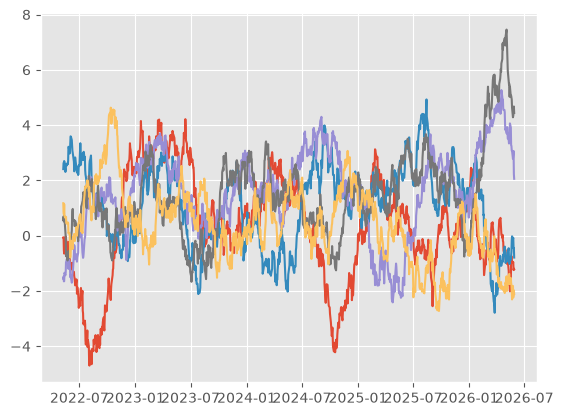

In [28]:
for fund in top5:

    temp = nav[nav["amfi_code"] == fund].copy()

    temp = temp.sort_values("nav_date")

    rolling_mean = temp["daily_return"].rolling(window=90).mean()

    rolling_std = temp["daily_return"].rolling(window=90).std()

    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

    plt.plot(
        temp["nav_date"],
        sharpe,
        label=fund
    )

C:\Users\sktec\AppData\Local\Temp\ipykernel_27784\1011853017.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


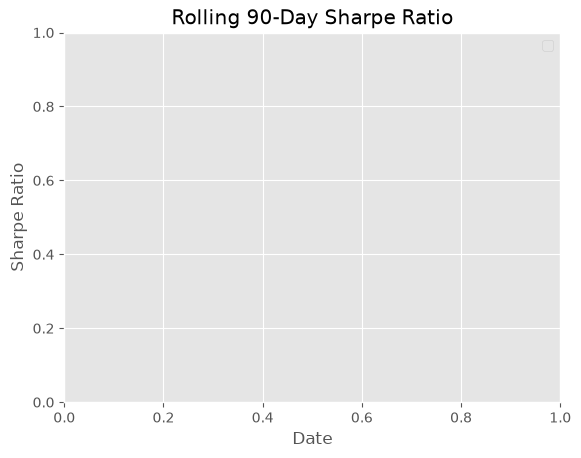

In [29]:
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

In [30]:
plt.savefig("rolling_sharpe_chart.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

Investor Cohort Analysis

In [31]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [32]:
transactions["transaction_year"] = (
    transactions["transaction_date"].dt.year
)

In [33]:
cohort = (
    transactions
    .groupby("investor_id")["transaction_year"]
    .min()
    .reset_index()
)

cohort.rename(
    columns={"transaction_year": "cohort_year"},
    inplace=True
)

In [34]:
transactions = transactions.merge(
    cohort,
    on="investor_id",
    how="left"
)

In [35]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
]

In [40]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'transaction_year', 'cohort_year']


In [41]:
avg_sip = (
    sip.groupby("cohort_year")["amount_inr"]
       .mean()
       .reset_index(name="Average_SIP_Amount")
)

In [42]:
top_fund = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

In [43]:
top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")["count"].idxmax()
]

In [44]:
top_fund = top_fund.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [47]:
total_investment = (
    transactions.groupby("cohort_year")["amount_inr"]
                .sum()
                .reset_index(name="Total_Invested")
)

In [46]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'transaction_year', 'cohort_year']


In [48]:
report = (
    avg_sip
    .merge(total_investment, on="cohort_year")
    .merge(
        top_fund[
            ["cohort_year", "scheme_name"]
        ],
        on="cohort_year"
    )
)

In [49]:
report.rename(
    columns={
        "scheme_name": "Top_Fund_Preference"
    },
    inplace=True
)

In [50]:
print(report)

   cohort_year  Average_SIP_Amount  Total_Invested  \
0         2024        10996.885825      3491125187   
1         2025        13505.209581        30455243   

                                 Top_Fund_Preference  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


In [51]:
report.to_csv("investor_cohort_report.csv", index=False)

SIP Continuity Analysis

In [52]:
sip = transactions[
transactions["transaction_type"]=="SIP"
]

In [53]:
sip = sip.sort_values(
["investor_id","transaction_date"]
)

In [54]:
sip["Gap"] = sip.groupby(
"investor_id"
)["transaction_date"].diff().dt.days

In [55]:
gap = sip.groupby("investor_id").agg(
Transactions=("Gap","count"),
Average_Gap=("Gap","mean")
)

In [56]:
gap = gap[
gap["Transactions"]>=6
]

In [57]:
gap["Status"] = np.where(
gap["Average_Gap"]>35,
"At Risk",
"Healthy"
)

Sector HHI

In [62]:
portfolio = pd.read_csv(
    r"D:\mutual fund project\day 2 Cleaned data  SQLite DB loaded\Data\raw\09_portfolio_holdings.csv"
)

In [63]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [64]:
portfolio["weight"] = portfolio["weight_pct"] / 100

In [65]:
portfolio["weight_squared"] = portfolio["weight"] ** 2

In [66]:
hhi = (
    portfolio.groupby("amfi_code")["weight_squared"]
             .sum()
             .reset_index()
)

hhi.rename(columns={"weight_squared": "HHI"}, inplace=True)

In [67]:
hhi = hhi.merge(
    funds[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

In [68]:
equity_hhi = hhi[
    hhi["category"].str.contains("Equity", case=False, na=False)
]

In [69]:
equity_hhi = equity_hhi.sort_values(
    "HHI",
    ascending=False
)

In [70]:
print(equity_hhi[["scheme_name", "HHI"]])

                                          scheme_name       HHI
11              Axis Bluechip Fund - Regular - Growth  0.206448
3              ABSL Small Cap Fund - Regular - Growth  0.200700
18          SBI Small Cap Fund - Direct Plan - Growth  0.174751
4          UTI Nifty 50 Index Fund - Regular - Growth  0.174709
7      Nippon India Large Cap Fund - Regular - Growth  0.168298
29  Mirae Asset Emerging Bluechip Fund - Regular -...  0.167930
21           ICICI Pru Midcap Fund - Regular - Growth  0.157570
22  ICICI Pru Value Discovery Fund - Regular - Growth  0.153794
27  HDFC Mid-Cap Opportunities Fund - Direct - Growth  0.152414
23             Kotak Bluechip Fund - Regular - Growth  0.149680
30      Mirae Asset Tax Saver Fund - Regular - Growth  0.149396
1   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.147592
32                 DSP Midcap Fund - Regular - Growth  0.141621
19         ICICI Pru Bluechip Fund - Regular - Growth  0.140870
0           HDFC Top 100 Fund - Regular 

In [71]:
equity_hhi.to_csv(
    "sector_hhi_report.csv",
    index=False
)

# Advanced Analytics Insights

## 1. Historical VaR and CVaR Analysis
The **SBI Small Cap Fund – Direct Plan – Growth** recorded the highest downside risk among all 40 schemes, with a **95% Value at Risk (VaR) of -2.69%** and a **Conditional Value at Risk (CVaR) of -3.24%**. This indicates that under the worst 5% of market conditions, the fund is expected to lose at least 2.69% in a single day, while the average loss during these extreme scenarios is approximately 3.24%. Small-cap funds generally exhibited higher downside risk than large-cap and index funds.

---

## 2. Rolling 90-Day Sharpe Ratio Analysis
The Rolling 90-Day Sharpe Ratio analysis revealed noticeable fluctuations in the risk-adjusted performance of the selected mutual funds over time. While some funds consistently maintained positive Sharpe Ratios, others experienced periods of negative Sharpe Ratios, reflecting changing market conditions. Overall, the analysis demonstrates that fund performance is dynamic and should be evaluated over time rather than relying solely on historical returns.

---

## 3. Investor Cohort Analysis
The **2024 investor cohort** accounted for the highest investment activity, contributing a total investment of **₹3,491,125,187** with an average SIP amount of **₹10,996.89**. The most preferred scheme among this cohort was **Mirae Asset Emerging Bluechip Fund – Regular Plan**, indicating strong investor confidence in diversified equity-oriented funds. Although the **2025 cohort** invested a smaller total amount (**₹30,455,243**), it recorded a higher average SIP amount of **₹13,505.21**, suggesting that newer investors are making larger SIP contributions.

---

## 4. SIP Continuity Analysis
The SIP continuity analysis was performed by calculating the average gap between consecutive SIP transactions for investors with at least six SIP installments. Investors whose average gap exceeded **35 days** were classified as **"At-Risk"**, enabling fund managers to identify investors who may discontinue their SIPs and implement timely retention strategies such as reminders and personalized engagement.

---
## 5. Fund Recommendation Analysis
The rule-based fund recommender successfully recommended funds based on investor risk appetite and Sharpe Ratio. For **Low-risk** investors, **ICICI Pru Liquid Fund – Regular – Growth** achieved the highest Sharpe Ratio (**13.66**). For **Moderate-risk** investors, **Mirae Asset Large Cap Fund – Regular – Growth** ranked first with a Sharpe Ratio of **1.91**. For **High-risk** investors, **Mirae Asset Tax Saver Fund – Regular – Growth** emerged as the top recommendation with a Sharpe Ratio of **1.60**. These recommendations provide investors with suitable fund choices based on historical risk-adjusted performance.

--- 
## 6. Sector Concentration (HHI) Analysis
The **Axis Bluechip Fund – Regular – Growth** recorded the highest **Herfindahl-Hirschman Index (HHI) of 0.2064**, indicating the highest sector concentration among the analyzed equity funds. It was followed by **ABSL Small Cap Fund – Regular – Growth (0.2007)** and **SBI Small Cap Fund – Direct Plan – Growth (0.1748)**. In contrast, funds such as **SBI Small Cap Fund – Regular Plan – Growth (0.1073)** and **SBI Bluechip Fund – Direct Plan – Growth (0.1080)** exhibited lower HHI values, reflecting better sector diversification and potentially lower concentration risk.